In [1]:
import random
import numpy as np

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

import matplotlib.pyplot as plt
import pandas as pd
import logging

logging.basicConfig(level=logging.INFO)

logger = logging.getLogger(__name__)

from pathlib import Path
import sys
import yaml

# Project root directory
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

# Load project configuration
with open(PROJECT_ROOT / "config.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)
    
    
# --- Data
from src.data.import_dataframe import import_dataframe
from src.data.merge_pathology_classes import merge_pathology_classes

# --- Features / Analysis
from src.analysis.compute_band_statistics import compute_band_statistics
from src.analysis.aggregate_band_statistics_per_class import aggregate_band_statistics_per_class
from src.analysis.build_experiment_config_names import build_experiment_config_names
from src.analysis.build_Xy import build_Xy
from src.analysis.run_intracorpus import run_intracorpus
from src.analysis.run_intracorpus_grid import run_intracorpus_grid
from src.analysis.flatten_results import flatten_results

# --- Visualization
from src.visualization.plot_mfbm_statistics_per_class import plot_mfbm_statistics_per_class
from src.visualization.plot_acoustic_features import plot_acoustic_features
from src.visualization.plot_results_bar_paper import plot_results_bar_paper
from src.visualization.plot_acoustic_confusion_matrices import plot_acoustic_confusion_matrices
from src.visualization.plot_metric_pcs_grid import plot_metric_pcs_grid
from src.visualization.plot_combined_violin import plot_combined_violin

# --- Evaluation
from src.evaluation.make_summary_table_paper_config import make_summary_table_paper_config
from src.evaluation.make_acoustic_configs_table import make_acoustic_configs_table
from src.evaluation.make_mean_by_mode_table import make_mean_by_mode_table
from src.evaluation.make_pc_analysis_tables import make_pc_analysis_tables


In [2]:
# ---------------------------------------------------------
# Load precomputed MFBM features for all configured corpora
# ---------------------------------------------------------

# Read the list of corpora from config
corpora_names = config["data"]["corpora"]

# Dynamically load all dataframes into a dictionary
datasets = {}
for name in corpora_names:
    datasets[name] = import_dataframe(
        name, input_root=str(PROJECT_ROOT / "data" / "processed")
    )

# --- Verification & Inspection Loop
for name, df in datasets.items():
    print(f"\n=== Inspecting {name} Dataframe structure ===")
    print(df.columns)


=== Inspecting mysMEEI Dataframe structure ===
Index(['file', 'age', 'gender', 'group', 'class', 'localjitter',
       'localshimmer', 'hnr', 'mfbm'],
      dtype='object')

=== Inspecting myUSP Dataframe structure ===
Index(['file', 'age', 'gender', 'group', 'class', 'localjitter',
       'localshimmer', 'hnr', 'mfbm'],
      dtype='object')



--- Processing Profile for Corpus: mysMEEI ---


INFO:src.visualization.plot_mfbm_statistics_per_class:MFBM per class plot saved to C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\results\figures\02_mysMEEI_mean_std_per_class.png


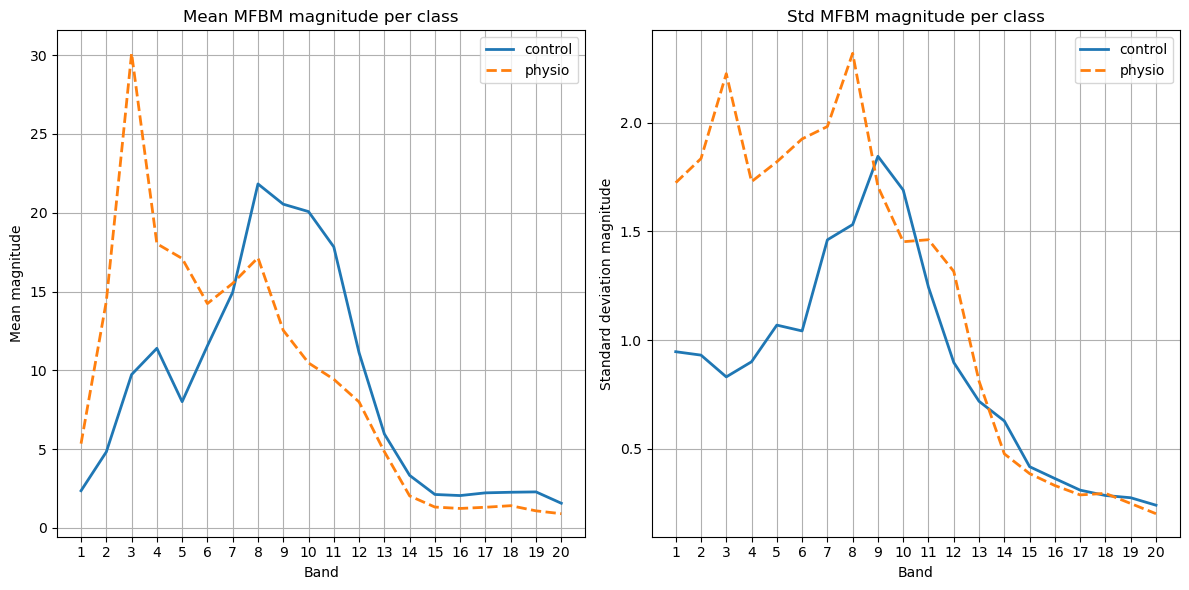


--- Processing Profile for Corpus: myUSP ---


INFO:src.visualization.plot_mfbm_statistics_per_class:MFBM per class plot saved to C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\results\figures\02_myUSP_mean_std_per_class.png


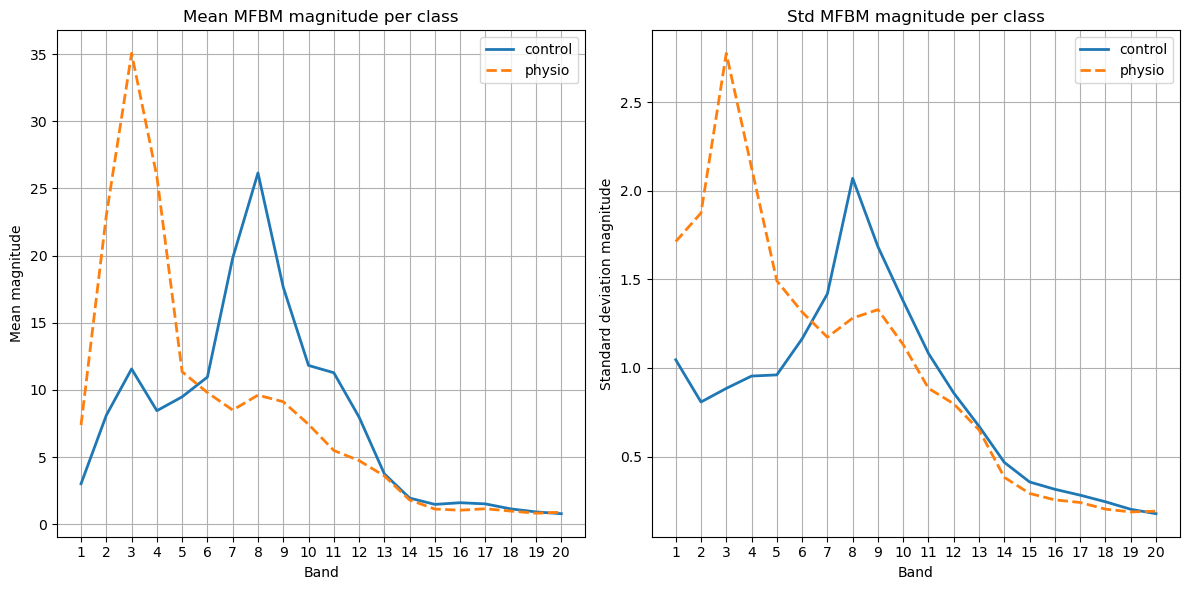

In [3]:
# ------------------------------------------------------------------
# Compute statistics, merge classes, and plot profiles per corpus
# ------------------------------------------------------------------

merge_cfg = config["class_merging"]
figures_dir = PROJECT_ROOT / config["results"]["figures_dir"]
metrics_dir = PROJECT_ROOT / config["results"]["metrics_dir"]

# Loop through each corpus in the dictionary
for dataset_name, df in datasets.items():
    print(f"\n--- Processing Profile for Corpus: {dataset_name} ---")

    # 1. Compute per-band mean and standard deviation statistics
    df = compute_band_statistics(df)

    # 2. Merge Reinke's edema and vocal nodules into a single 'physio' class
    df = merge_pathology_classes(
        df,
        classes_to_merge=merge_cfg["groups_to_merge"],        
        merged_label=merge_cfg["merged_label"]
    )

    # Re-save the processed dataframe back into the dictionary
    # so that the next steps of the pipeline (like ML) use the updated data
    datasets[dataset_name] = df

    # 3. Aggregate statistics and generate profiles per class
    mean_dict, std_dict = aggregate_band_statistics_per_class(df)

    # Define a dynamic path including the dataset name to avoid overwriting files
    output_image_path = figures_dir / f"02_{dataset_name}_mean_std_per_class.png"

    plot_mfbm_statistics_per_class(
        mean_dict, std_dict, save_path=str(output_image_path)
    )

=== Generating Acoustic Feature Plots ===


INFO:src.visualization.plot_acoustic_features:Acoustic features per class plot saved to C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\results\figures\03_mysMEEI_acoustic_features_per_class.png


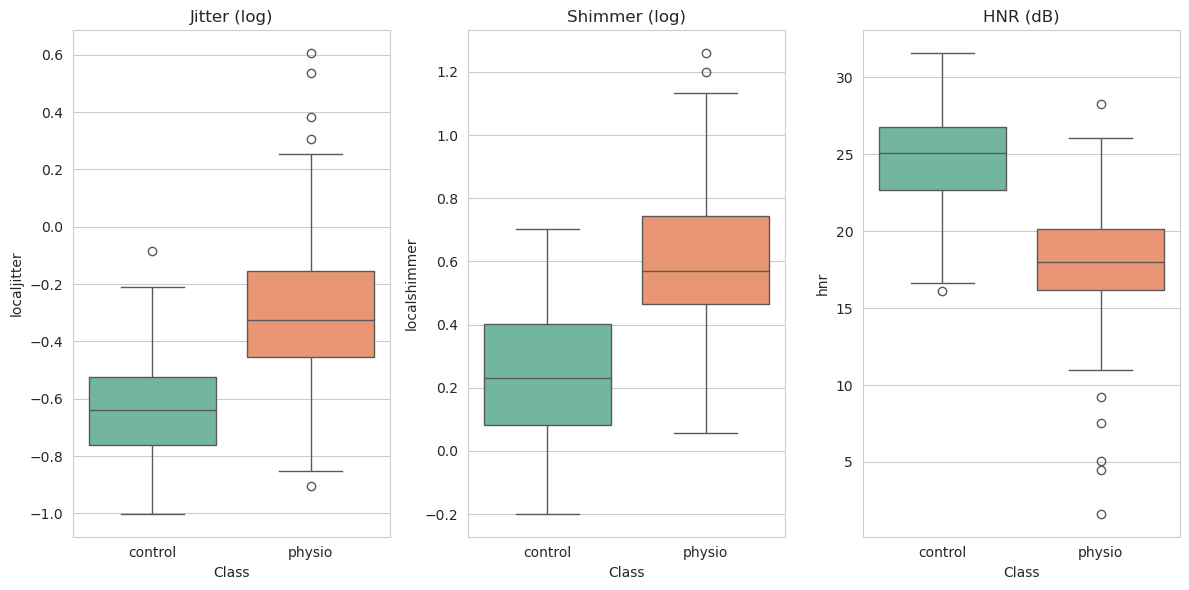

=== Generating Acoustic Feature Plots ===


INFO:src.visualization.plot_acoustic_features:Acoustic features per class plot saved to C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\results\figures\03_myUSP_acoustic_features_per_class.png


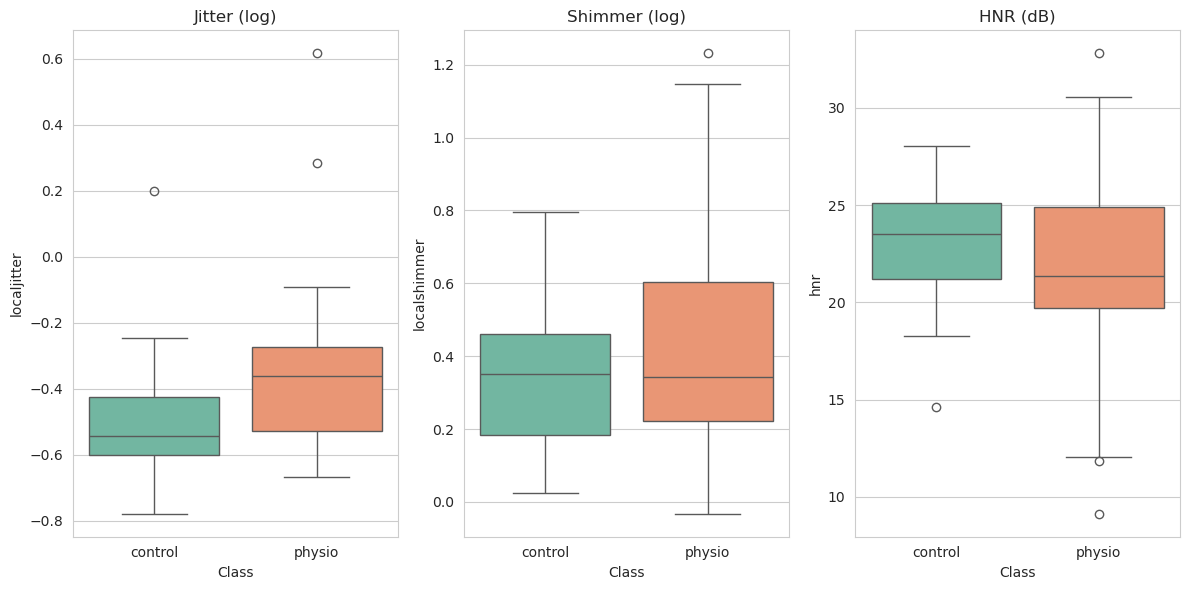

In [4]:
# ---------------------------------------------------------
# Plot acoustic features per class for all configured corpora
# ---------------------------------------------------------

# Loop dynamically through all datasets in the dictionary
for dataset_name, df in datasets.items():
    # Construct the dynamic save path using the dataset name
    
    save_path = (
        figures_dir /
        f"03_{dataset_name}_acoustic_features_per_class.png"
    )
    plot_acoustic_features(
        df,
        log_transform=[],
        save_path=str(save_path),       
    )

In [5]:
# ==========================================================
# Paper configuration
# ==========================================================
#
# PCA is applied independently to:
#   - mean_MFBM bands 1-6  (2 PCs)
#   - mean_MFBM bands 7-12 (1 PC)
#   - std_MFBM  bands 1-6  (2 PCs)
#   - std_MFBM  bands 7-12 (1 PC)
#
# Acoustic features are used without PCA.
#
# ==========================================================
# Experimental configurations
# ==========================================================
#
# The following experiments evaluate different PCA strategies
# by varying the number of retained principal components (PCs).
#
# acoustic
#   - Acoustic features only
#   - No PCA
#
# acoustic_balanced_weights
#   - Acoustic features only
#   - No PCA
#   - SVM with balanced class weights
#
# spectral_paper
#   - Paper spectral configuration
#   - Spectral features only (6 dimensions)
#
# combined_paper
#   - Paper combined configuration
#   - Spectral + acoustic features (9 dimensions)
#
# spectral_xx
#   - PCA applied only to spectral features
#   - xx retained spectral PCs
#
# combined_xx
#   - Joint PCA applied to spectral and acoustic features
#   - xx retained PCs
#
# sep_xx_raw
#   - PCA applied only to spectral features
#   - Acoustic features kept in the original space
#
# sep_xx_a01
#   - PCA applied separately to spectral features
#   - Acoustic features reduced to 1 PC
#
# sep_xx_a02
#   - PCA applied separately to spectral features
#   - Acoustic features reduced to 2 PCs


pca_cfg = config["pca"]["retained_components"]

# Feature sets to evaluate — each will be tested on every task
used_configs = build_experiment_config_names(
    pca_cfg["min"],
    pca_cfg["max"],
)

In [6]:
# ------------------------------------------------------------------
# Run all experiments
# ------------------------------------------------------------------

# Run all experiments for all corpora
all_results = []

for name in corpora_names:

    results = run_intracorpus_grid(
        run_intracorpus,
        datasets,
        train_corpus=name,
        feature_sets=used_configs,
        num_iters=config["experiments"]["num_iters"],
        print_report=False,
    )

    all_results.extend(results)



In [7]:
# Convert results into tidy format
tidy_metrics, tidy_cm = flatten_results(all_results)

# Export metrics
tidy_metrics.to_csv(
    metrics_dir /
    "01_intracorpus_tidy_metrics.csv",
    index=False,
    sep=";"
)
# Export confusion matrices
tidy_cm.to_csv(
    metrics_dir /
    "01_intracorpus_tidy_cm.csv",
    index=False,
    sep=";"
)

# PAPER CONFIG ANALYSIS

In [8]:
# =====================================================
# build table
# =====================================================

table_paper = make_summary_table_paper_config(tidy_metrics)

# =====================================================
# show tables
# =====================================================

print("\n==============================")
print("Paper Configurations Results")
print("==============================")
print(table_paper)

# Export sumarized results
    
table_paper.to_csv(    
        metrics_dir /
        "02_summarized_intracorpus_results_paper.csv",
        index=False,
        sep=";"
)


Paper Configurations Results
  train_corpus test_corpus        features    Accuracy            AUC
3      mysMEEI     mysMEEI        acoustic  83.7 ± 0.8  0.878 ± 0.006
5      mysMEEI     mysMEEI  spectral_paper  87.8 ± 1.2  0.933 ± 0.009
4      mysMEEI     mysMEEI  combined_paper  92.3 ± 1.2  0.962 ± 0.004
0        myUSP       myUSP        acoustic  65.0 ± 2.3  0.621 ± 0.044
2        myUSP       myUSP  spectral_paper  97.2 ± 2.6  0.997 ± 0.004
1        myUSP       myUSP  combined_paper  94.7 ± 1.5  0.990 ± 0.005


INFO:src.visualization.plot_results_bar_paper:accuracy bar plot saved to C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\results\figures\04_accuracy_paper_config.png


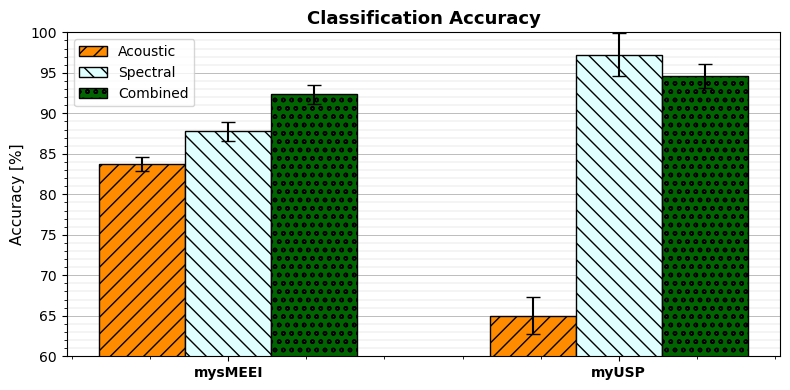

INFO:src.visualization.plot_results_bar_paper:auc bar plot saved to C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\results\figures\04_auc_paper_config.png


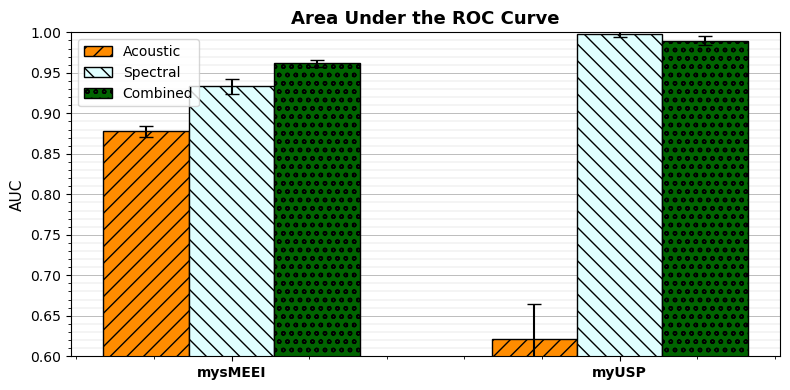

In [9]:
# visualize Accuracy
plot_results_bar_paper(
    tidy_metrics,
    metric="accuracy",
    save_path = str(
        figures_dir /
        "04_accuracy_paper_config.png"
    )
)

# visualize AUC
plot_results_bar_paper(
    tidy_metrics,
    metric="auc",
    save_path = str(
        figures_dir /
        "04_auc_paper_config.png"
    )
)

# PCA COMPONENT-BASED CONFIGS ANALYSIS

INFO:src.visualization.plot_metric_pcs_grid:accuracy results plot successfully saved to: C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\results\figures\05_accuracy_results.png


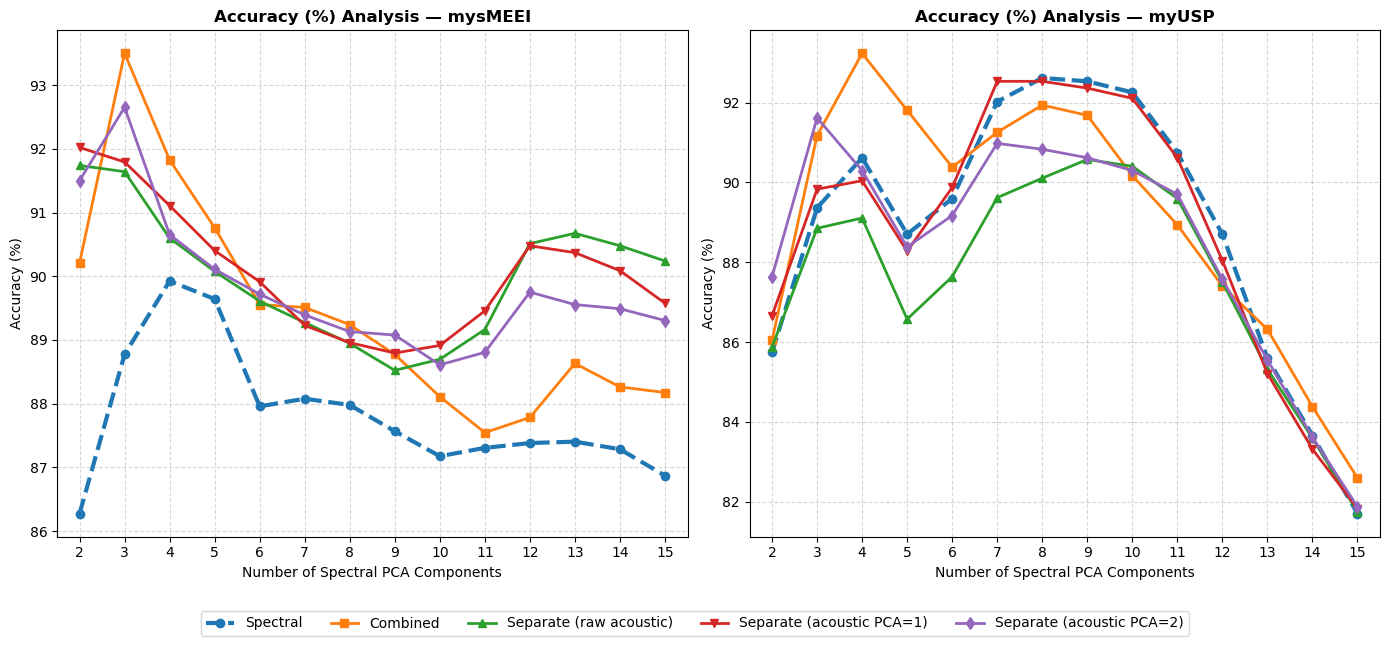

INFO:src.visualization.plot_metric_pcs_grid:auc results plot successfully saved to: C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\results\figures\05_auc_results.png


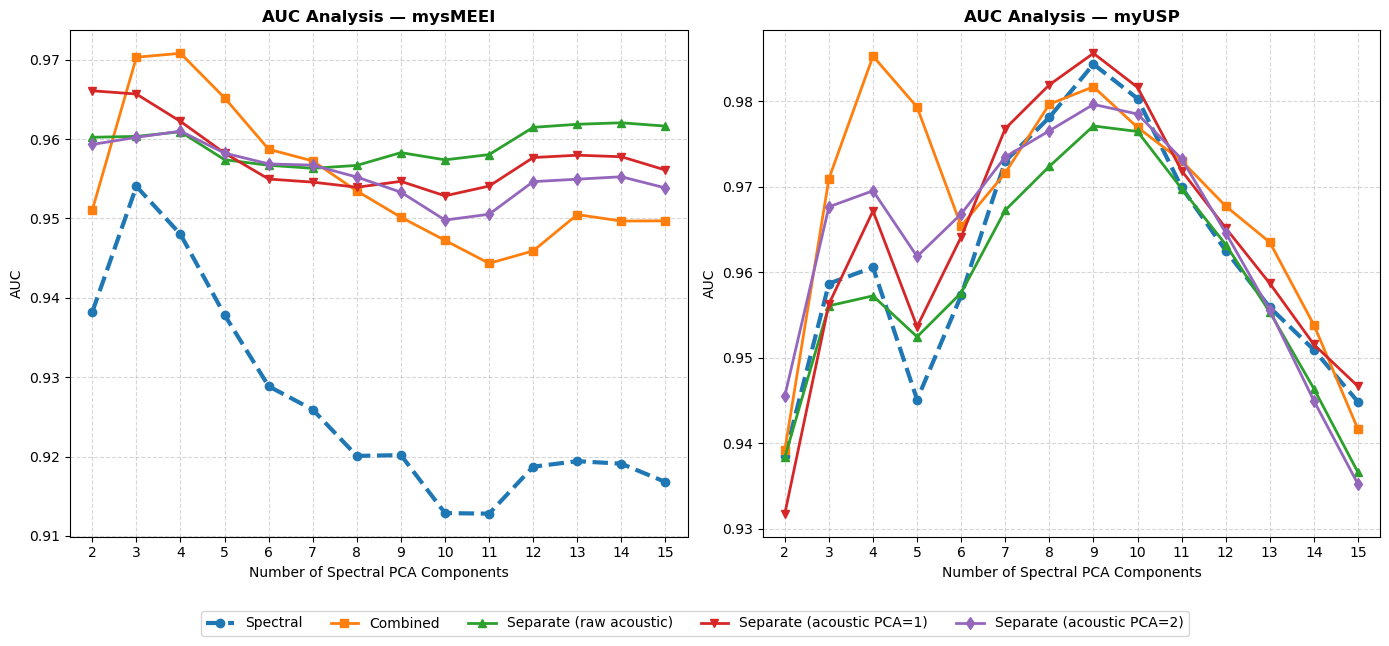

In [10]:
# =====================================================
# Show variable kept PCs results
# =====================================================

metrics_to_plot = ['accuracy', 'auc']

for mtp in metrics_to_plot:
    save_path = (
        figures_dir /
        f"05_{mtp}_results.png"
    )
    plot_metric_pcs_grid(
        tidy_metrics,
        metric_name=mtp,
        save_path=str(save_path),       
    )


In [11]:
# =====================================================
# build table
# =====================================================

mean_by_mode_table = make_mean_by_mode_table(tidy_metrics)

# =====================================================
# show tables
# =====================================================

print("\n==================================")
print("Metrics Mean Value by Mode Results")
print("==================================")
print(mean_by_mode_table)

# Export table
    
mean_by_mode_table.to_csv(    
        PROJECT_ROOT /
        config["results"]["metrics_dir"] /
        "03_intracorpus_mean_by_mode.csv",
        index=True,
        sep=";"
)


Metrics Mean Value by Mode Results
                                  acoustic spectral combined sep_raw sep_a1  \
train_corpus test_corpus metric                                               
mysMEEI      mysMEEI     accuracy    84.2%    87.8%    89.4%   90.0%  90.1%   
                         auc         0.874    0.927    0.955   0.959  0.958   
myUSP        myUSP       accuracy    64.5%    88.8%    89.1%   87.6%  88.8%   
                         auc         0.644    0.961    0.968   0.959  0.964   

                                  sep_a2  
train_corpus test_corpus metric           
mysMEEI      mysMEEI     accuracy  89.8%  
                         auc       0.956  
myUSP        myUSP       accuracy  88.4%  
                         auc       0.964  


In [12]:
# =====================================================
# Show results per config (components)
# Spectral, mean combined, best combined and best conbined config
# =====================================================

# Build tables
# Run the pipeline function
tables_per_nr_pcs = make_pc_analysis_tables(
    tidy_metrics, target_feature_sMEEI="sep_a01", target_feature_USP="combined"
)


for name in corpora_names:
    # 1. Dynamic print using the loop variable
    print(f"=== {name.upper()} ANALYSIS TABLE ===")
    display(tables_per_nr_pcs[name])

    # 2. Dynamic filename using f-string to inject the corpus name
    filename = f"04_intracorpus_results_per_spectral_pcs_{name}.csv"

    # 3. Save the correct table
    tables_per_nr_pcs[name].to_csv(
        metrics_dir / filename,
        index=True, 
        sep=";",
    )


=== MYSMEEI ANALYSIS TABLE ===


,spectral_acc,mean_comb_acc,best_comb_acc,sep_a01_acc
spec_pca,,,,
2,86.3%,91.4%,92.0%,92.0%
3,88.8%,92.4%,93.5%,91.8%
4,89.9%,91.0%,91.8%,91.1%
5,89.6%,90.3%,90.8%,90.4%
6,88.0%,89.7%,89.9%,89.9%
7,88.1%,89.4%,89.5%,89.2%
8,88.0%,89.1%,89.2%,89.0%
9,87.6%,88.8%,89.1%,88.8%
10,87.2%,88.6%,88.9%,88.9%


=== MYUSP ANALYSIS TABLE ===


,spectral_acc,mean_comb_acc,best_comb_acc,combined_acc
spec_pca,,,,
2,85.7%,86.6%,87.6%,86.0%
3,89.4%,90.4%,91.6%,91.2%
4,90.6%,90.7%,93.2%,93.2%
5,88.7%,88.8%,91.8%,91.8%
6,89.6%,89.3%,90.4%,90.4%
7,92.0%,91.1%,92.5%,91.3%
8,92.6%,91.4%,92.5%,91.9%
9,92.5%,91.3%,92.4%,91.7%
10,92.3%,90.7%,92.1%,90.2%


INFO:src.visualization.plot_combined_violin:Violin plot successfully saved to: C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\results\figures\06_Accuracy_results.png


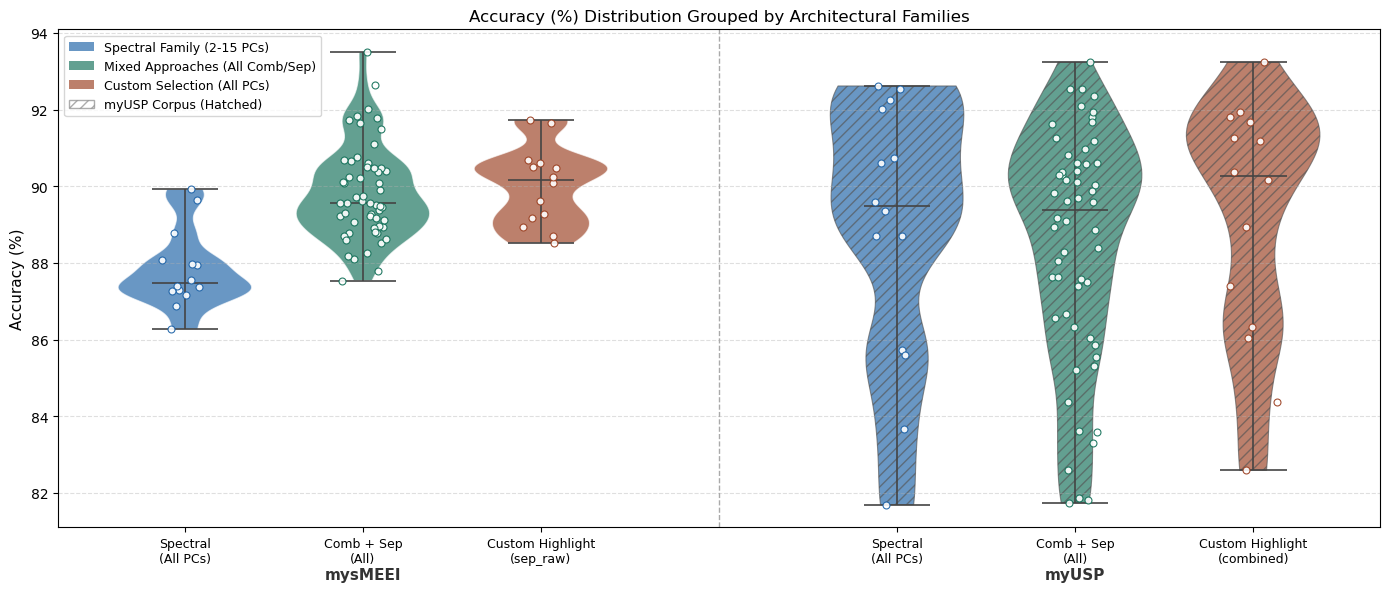

INFO:src.visualization.plot_combined_violin:Violin plot successfully saved to: C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\results\figures\06_AUC_results.png


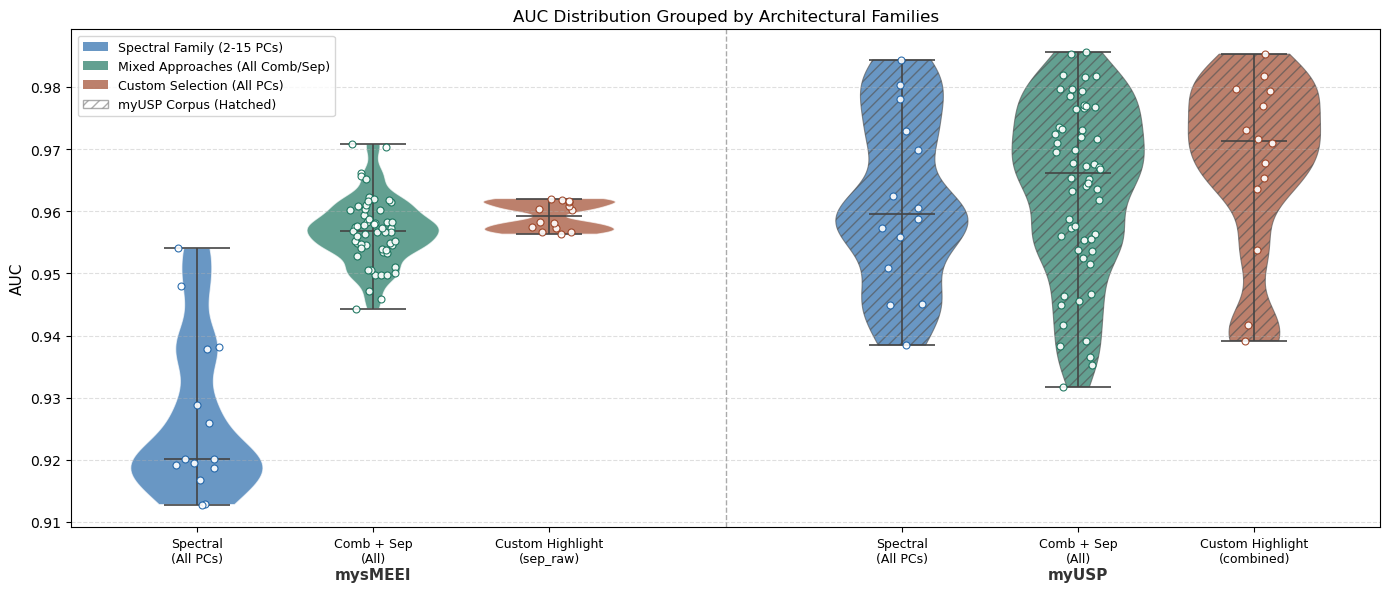

In [13]:
# =====================================================
# Visualize metric results
# =====================================================

# Accuracy
plot_combined_violin(
    tidy_metrics,
    metric_name="accuracy",
    custom_config_sMEEI="sep_raw",  
    custom_config_USP="combined", 
    save_path = (
        figures_dir /
        f"06_Accuracy_results.png"
    )
)

# AUC
plot_combined_violin(
    tidy_metrics,
    metric_name="auc",
    custom_config_sMEEI="sep_raw", 
    custom_config_USP="combined", 
        save_path = (
        figures_dir /
        f"06_AUC_results.png"
    )
)

# ACOUSTIC RESULTS ANALYSIS

In [14]:
# Building table with only acoustic configuration results
table_acoustic_config = make_acoustic_configs_table(tidy_metrics)

# Visualizing the table
print(table_acoustic_config)

# saving the table
table_acoustic_config.to_csv(    
        PROJECT_ROOT /
        config["results"]["metrics_dir"] /
        "05_summarized_intracorpus_acoustic_results.csv",
        index=False,
        sep=";"
)


                                        acoustic acoustic_balanced_weights
train_corpus test_corpus metric                                           
mysMEEI      mysMEEI     accuracy   83.7% ± 0.8%              84.6% ± 1.2%
                         auc       0.878 ± 0.006             0.871 ± 0.008
myUSP        myUSP       accuracy   65.0% ± 2.3%              64.1% ± 4.0%
                         auc       0.621 ± 0.044             0.667 ± 0.032


INFO:src.visualization.plot_acoustic_confusion_matrices:Acoustic configs confusion matrices of mysMEEI plot saved to C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\results\figures\07_mysMEEI_acoustic_configs_confusion_matrices.png


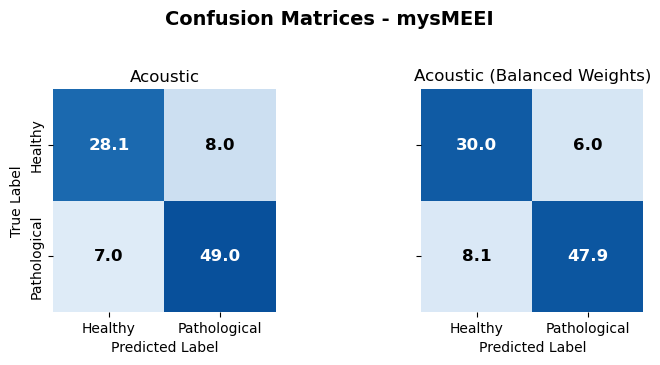

INFO:src.visualization.plot_acoustic_confusion_matrices:Acoustic configs confusion matrices of myUSP plot saved to C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\results\figures\07_myUSP_acoustic_configs_confusion_matrices.png


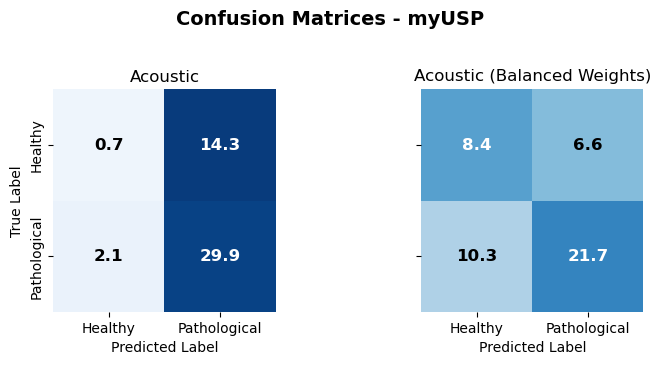

In [15]:
# Loop dynamically through corpora names
for name in corpora_names:
    
    # Construct the dynamic save path using the dataset name    
    save_path = (
        figures_dir /
        f"07_{name}_acoustic_configs_confusion_matrices.png"
    )
    
    #Visualize
    plot_acoustic_confusion_matrices(
        tidy_cm_df=tidy_cm, 
        test_corpus=name,
        save_path=str(save_path),       
    )